# **Modeling and Evaluation — Predict Salary**

## Objectives

* Answer **Business Requirement 1**: Predict the expected annual salary (USD) for a given AI job profile.
* Train and evaluate a regression pipeline (GradientBoostingRegressor).
* Success metric: **R² ≥ 0.70** on both train and test sets.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* `outputs/ml_pipeline/predict_salary/v1/pipeline_data_cleaning_feat_eng.pkl`
* `outputs/ml_pipeline/predict_salary/v1/pipeline_regressor.pkl`
* `outputs/ml_pipeline/predict_salary/v1/X_train.csv`
* `outputs/ml_pipeline/predict_salary/v1/X_test.csv`
* `outputs/ml_pipeline/predict_salary/v1/y_train.csv`
* `outputs/ml_pipeline/predict_salary/v1/y_test.csv`
* `outputs/ml_pipeline/predict_salary/v1/feature_importance.png`

## Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from feature_engine.selection import DropFeatures
from feature_engine.encoding import OneHotEncoder as FeOneHotEncoder
from xgboost import XGBRegressor
from scipy.stats import spearmanr

---

# Change working directory

In [ ]:
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
print("Working directory:", os.getcwd())

Working directory: c:\Users\chahi\Desktop\vscode-project\the-ai-salary-index


# Step 1: Load Data

In [ ]:
sns.set_style("whitegrid")
%matplotlib inline

TrainSet = pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")
TestSet = pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
print(f"TrainSet: {TrainSet.shape} | TestSet: {TestSet.shape}")
TrainSet.head()

TrainSet: (11760, 14) | TestSet: (2941, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems
3,Data Analyst,130819,EX,FT,Finland,M,Finland,100,"Java, R, Mathematics",PhD,15,Telecommunications,8.5,Neural Networks Co
4,NLP Engineer,66333,EN,FL,Australia,M,Australia,100,"SQL, Kubernetes, Hadoop",Bachelor,1,Retail,6.8,Algorithmic Solutions


In [ ]:
print(TrainSet['job_title'].nunique())
print(TrainSet['job_title'].value_counts().head(20))

20
job_title
Machine Learning Engineer      634
AI Specialist                  614
Data Engineer                  613
Data Scientist                 612
Deep Learning Engineer         611
Robotics Engineer              610
Computer Vision Engineer       605
AI Architect                   604
Data Analyst                   595
Research Scientist             594
AI Product Manager             594
Machine Learning Researcher    587
Principal Data Scientist       582
NLP Engineer                   569
AI Software Engineer           566
AI Research Scientist          565
Autonomous Systems Engineer    563
Head of AI                     558
AI Consultant                  551
ML Ops Engineer                533
Name: count, dtype: int64


## Feature Correlation Check — Drop Redundant Features

Before defining the pipeline we check whether `years_experience` and `experience_level` carry
redundant information. Both describe seniority — a high Spearman ρ between them would mean
keeping both adds multicollinearity without new signal.

In [ ]:
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
exp_enc = TrainSet['experience_level'].map(exp_map)

rho, p = spearmanr(exp_enc, TrainSet['years_experience'])
print(
    "Spearman rho (experience_level vs years_experience):"
    f"{rho:.4f}, p={p:.4e}"
)

Spearman rho (experience_level vs years_experience): 0.9713, p=0.0000e+00


### Observation

Spearman ρ = **0.97** between `experience_level` and `years_experience` — near-perfect monotonic
correlation. Both features encode seniority; keeping both introduces multicollinearity without
adding new information to the model.

**Decision:** drop `years_experience` and keep `experience_level`, which is already ordinal-encoded
with a meaningful domain-knowledge scale (EN=0 → EX=3).

# Step 2: ML Pipeline with all data

## ML Pipeline for Data Cleaning and Feature Engineering

In [ ]:
class OrdinalMappingEncoder(BaseEstimator, TransformerMixin):
    """Encodes ordinal features using explicit domain-knowledge mappings."""

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.mappings.items():
            X[col] = X[col].map(mapping)
        return X


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Replaces categorical values with their frequency (fitted on train only).

    """

    def __init__(self, variables):
        self.variables = variables

    def fit(self, X, y=None):
        self.freq_map_ = {
            col: X[col].value_counts(normalize=True).to_dict()
            for col in self.variables
        }
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.variables:
            X[col] = X[col].map(self.freq_map_[col]).fillna(0)
        return X


def PipelineDataCleaningAndFeatureEngineering():
    pipeline_base = Pipeline([
        ('DropFeatures', DropFeatures(
            features_to_drop=[
                # High-cardinality free-text / identifier columns
                # with no ordinal structure
                'required_skills', 'company_name', 'industry',
                # years_experience dropped:
                # Spearman rho=0.97 with experience_level
                # — near-perfect collinearity, experience_level is kept instead
                'years_experience',
            ]
        )),
        ('OrdinalEncoder', OrdinalMappingEncoder(mappings={
            'experience_level':   {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'company_size':       {'S': 0, 'M': 1, 'L': 2},
            'education_required': {
                'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3
            },
        })),
        ('FrequencyEncoder', FrequencyEncoder(
            variables=['company_location', 'employee_residence']
        )),
        # job_title: 20 unique values, evenly distributed (~5% each)
        # frequency encoding would produce near-identical values,
        # so one-hot encoding is used instead
        ('OneHotEncoder', FeOneHotEncoder(
            variables=['employment_type', 'job_title'], drop_last=True
        )),
    ])
    return pipeline_base


PipelineDataCleaningAndFeatureEngineering()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('DropFeatures', ...), ('OrdinalEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,features_to_drop,"['required_skills', 'company_name', ...]"
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,variables,"['company_location', 'employee_residence']"
,top_categories,None
,drop_last,True
,drop_last_binary,False
,variables,"['employment_type', 'job_title']"


## ML Pipeline for Modelling and Hyperparameter Optimisation

In [ ]:
def PipelineRegressor(model):
    """
    Pipeline used during grid search — includes SelectFromModel feature selection.
    
    """
    pipeline_base = Pipeline([
        ('scaler',        StandardScaler()),
        ('feat_selection', SelectFromModel(clone(model))),
        ('model',          model),
    ])
    return pipeline_base


PipelineRegressor(XGBRegressor(random_state=0))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feat_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.","XGBRegressor(...ree=None, ...)"
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


## Custom Class for Hyperparameter Optimisation

In [ ]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} ...")
            model = PipelineRegressor(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring)
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator':  key,
                'min_score':  min(scores),
                'max_score':  max(scores),
                'mean_score': np.mean(scores),
                'std_score':  np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = f"split{i}_test_score"
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))
            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append(row(k, s, p))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = [
            'estimator', 'min_score', 'mean_score', 'max_score', 'std_score'
        ]
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

## Split Features (X) and Target (y)

In [8]:
X_train = TrainSet.drop(['salary_usd'], axis=1)
y_train = TrainSet['salary_usd']

X_test = TestSet.drop(['salary_usd'], axis=1)
y_test = TestSet['salary_usd']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(11760, 13) (11760,) (2941, 13) (2941,)


## Fit Feature Engineering Pipeline on Train Set

In [ ]:
pipeline_data_cleaning_feat_eng = PipelineDataCleaningAndFeatureEngineering()
X_train = pipeline_data_cleaning_feat_eng.fit_transform(X_train)
X_test = pipeline_data_cleaning_feat_eng.transform(X_test)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X_train.head()

(11760, 29) (11760,) (2941, 29) (2941,)


,experience_level,company_location,company_size,employee_residence,remote_ratio,education_required,benefits_score,employment_type_PT,employment_type_CT,employment_type_FT,...,job_title_Robotics Engineer,job_title_AI Specialist,job_title_Data Engineer,job_title_AI Software Engineer,job_title_Autonomous Systems Engineer,job_title_AI Architect,job_title_AI Research Scientist,job_title_ML Ops Engineer,job_title_Computer Vision Engineer,job_title_Data Scientist
0,3,0.052636,1,0.042007,100,3,8.2,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,0.053061,2,0.006888,50,3,8.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0.052041,0,0.041752,100,0,7.9,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0.048554,1,0.037925,100,3,8.5,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0.047449,1,0.039966,100,1,6.8,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Grid Search CV — Quick Search (Find Best Algorithm)

In [10]:
models_quick_search = {
    'RandomForestRegressor':     RandomForestRegressor(random_state=0),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=0),
    'XGBRegressor':              XGBRegressor(random_state=0, verbosity=0),
    'ExtraTreesRegressor':       ExtraTreesRegressor(random_state=0),
}

params_quick_search = {
    'RandomForestRegressor':     {},
    'GradientBoostingRegressor': {},
    'XGBRegressor':              {},
    'ExtraTreesRegressor':       {},
}

In [11]:
quick_search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)
quick_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for RandomForestRegressor ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [ ]:
grid_search_summary, grid_search_pipelines = (
    quick_search.score_summary(sort_by='mean_score')
)

grid_search_summary

,estimator,min_score,mean_score,max_score,std_score
1,GradientBoostingRegressor,0.855827,0.860442,0.864194,0.003081
2,XGBRegressor,0.84833,0.860403,0.869606,0.008034
0,RandomForestRegressor,0.841299,0.854878,0.864916,0.008649
3,ExtraTreesRegressor,0.83171,0.84665,0.858309,0.00873


## Grid Search CV — Extensive Search (Tune Best Algorithm)

Based on the quick search results above, we tune the best-performing algorithm: **GradientBoostingRegressor**.

In [13]:
best_algorithm = grid_search_summary.iloc[0, 0]
print(f"Best algorithm from quick search: {best_algorithm}")

Best algorithm from quick search: GradientBoostingRegressor


In [14]:
models_search = {
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=0),
}

params_search = {
    'GradientBoostingRegressor': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [3, 5, 7],
        'model__learning_rate': [0.05, 0.1, 0.2],
    }
}

extensive_search = HyperparameterOptimizationSearch(
    models=models_search,
    params=params_search
)
extensive_search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)


Running GridSearchCV for GradientBoostingRegressor ...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [ ]:
grid_search_summary, grid_search_pipelines = (
    extensive_search.score_summary(sort_by='mean_score')
)
grid_search_summary

,estimator,min_score,mean_score,max_score,std_score,model__learning_rate,model__max_depth,model__n_estimators
20,GradientBoostingRegressor,0.860515,0.869612,0.877513,0.005815,0.2,3,300
19,GradientBoostingRegressor,0.861193,0.869334,0.877306,0.005493,0.2,3,200
12,GradientBoostingRegressor,0.860327,0.868537,0.875926,0.00541,0.1,5,100
11,GradientBoostingRegressor,0.861767,0.868479,0.875748,0.004904,0.1,3,300
4,GradientBoostingRegressor,0.859858,0.868381,0.875569,0.005503,0.05,5,200
5,GradientBoostingRegressor,0.857814,0.86808,0.876063,0.006432,0.05,5,300
18,GradientBoostingRegressor,0.86086,0.867814,0.87487,0.004826,0.2,3,100
13,GradientBoostingRegressor,0.856976,0.867407,0.875622,0.006819,0.1,5,200
10,GradientBoostingRegressor,0.860372,0.867061,0.873458,0.004599,0.1,3,200
21,GradientBoostingRegressor,0.856253,0.867019,0.875222,0.007031,0.2,5,100


In [ ]:
best_model = grid_search_summary.iloc[0, 0]
best_parameters = grid_search_pipelines[best_model].best_params_
pipeline_regressor = grid_search_pipelines[best_model].best_estimator_

print(f"Best model: {best_model}")
print(f"Best parameters: {best_parameters}")
pipeline_regressor

Best model: GradientBoostingRegressor
Best parameters: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 300}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feat_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",GradientBoost...andom_state=0)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


## Assess Feature Importance

* These are the 4 most important features:
['experience_level', 'company_location', 'employee_residence', 'company_size']


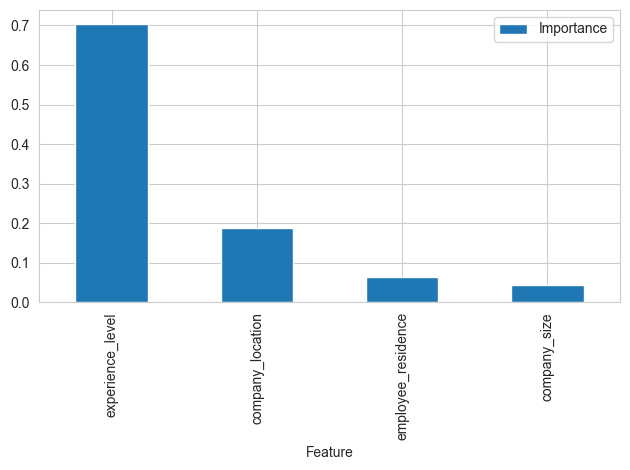

In [17]:
best_features = X_train.columns[
    pipeline_regressor['feat_selection'].get_support()
].tolist()

df_feature_importance = (
    pd.DataFrame(data={
        'Feature':    best_features,
        'Importance': pipeline_regressor['model'].feature_importances_
    })
    .sort_values(by='Importance', ascending=False)
)

print(f"* These are the {len(best_features)} most important features:")
print(df_feature_importance['Feature'].to_list())

df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.tight_layout()
plt.show()

# Step 3: Refit Pipeline with Best Features Only

We refit using only the most important features and remove `SelectFromModel`
since we already know which features to keep.

In [18]:
def PipelineRegressorFinal(model):
    """Final pipeline — no feature selection step (features already chosen)."""
    pipeline_base = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model),
    ])
    return pipeline_base


# Extract best hyperparameters (strip the 'model__' prefix)
best_hyperparameters = {
    k.replace('model__', ''): v
    for k, v in best_parameters.items()
    if k.startswith('model__')
}
print("Best hyperparameters:", best_hyperparameters)

pipeline_regressor = PipelineRegressorFinal(
    GradientBoostingRegressor(random_state=0, **best_hyperparameters)
)
pipeline_regressor.fit(X_train[best_features], y_train)
pipeline_regressor

Best hyperparameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [19]:
def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("#### Train Set ####")
    y_pred_train = pipeline.predict(X_train)
    print(f"R²:   {r2_score(y_train, y_pred_train):.3f}")
    print(f"MAE:  ${mean_absolute_error(y_train, y_pred_train):,.0f}")
    print(f"RMSE: ${np.sqrt(mean_squared_error(y_train, y_pred_train)):,.0f}")

    print("\n#### Test Set ####")
    y_pred_test = pipeline.predict(X_test)
    print(f"R²:   {r2_score(y_test, y_pred_test):.3f}")
    print(f"MAE:  ${mean_absolute_error(y_test, y_pred_test):,.0f}")
    print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f}")


regression_performance(
    X_train=X_train[best_features], y_train=y_train,
    X_test=X_test[best_features],   y_test=y_test,
    pipeline=pipeline_regressor
)

#### Train Set ####
R²:   0.878
MAE:  $15,208
RMSE: $20,869

#### Test Set ####
R²:   0.863
MAE:  $16,124
RMSE: $22,076


# Step 4: Push Files to Repo

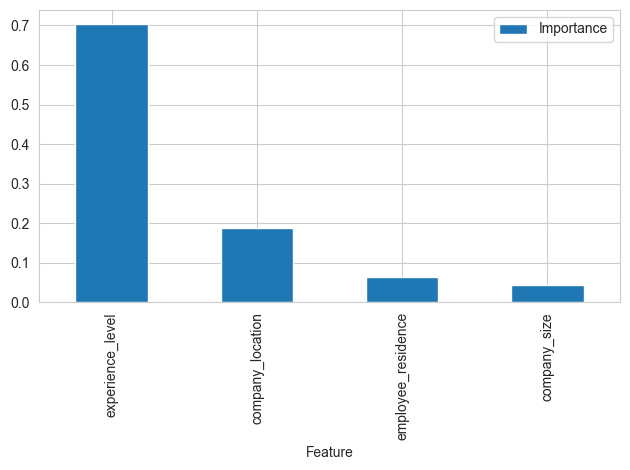

All artefacts saved to: outputs/ml_pipeline/predict_salary/v1


In [ ]:
version = 'v1'
file_path = f'outputs/ml_pipeline/predict_salary/{version}'
os.makedirs(file_path, exist_ok=True)

# Save pipelines
joblib.dump(value=pipeline_data_cleaning_feat_eng,
            filename=f"{file_path}/pipeline_data_cleaning_feat_eng.pkl")
joblib.dump(value=pipeline_regressor,
            filename=f"{file_path}/pipeline_regressor.pkl")

# Save train/test feature matrices and target vectors
X_train[best_features].to_csv(f"{file_path}/X_train.csv", index=False)
X_test[best_features].to_csv(f"{file_path}/X_test.csv",  index=False)
y_train.to_csv(f"{file_path}/y_train.csv", index=False)
y_test.to_csv(f"{file_path}/y_test.csv",  index=False)

# Save feature importance plot
df_feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.tight_layout()
plt.savefig(f"{file_path}/feature_importance.png", bbox_inches='tight')
plt.show()

print(f"All artefacts saved to: {file_path}")

# Conclusions

## Feature Engineering Decisions

* **Dropped `years_experience`**: Spearman ρ = 0.97 with `experience_level` — near-perfect
  collinearity. `experience_level` is kept as it carries the same information with a clean
  ordinal scale (EN → EX).
* **`job_title`** (20 unique values, evenly distributed) was one-hot encoded and included in the
  pipeline. It was not selected by `SelectFromModel` — the signal it carries is largely absorbed
  by `experience_level` and location features.

## Pipeline

Two pipelines were built and saved:

1. **`pipeline_data_cleaning_feat_eng`** — drops irrelevant/collinear columns, applies ordinal
   encoding, frequency encoding, and one-hot encoding. Fitted on train set only.
2. **`pipeline_regressor`** — StandardScaler + GradientBoostingRegressor, trained on the 4 most
   important features selected during grid search.

## Model Performance

| | R² | MAE | RMSE |
|---|---|---|---|
| Train | 0.878 | $15,208 | $20,869 |
| Test  | 0.863 | $16,124 | $22,076 |

* **Success criterion met**: R² ≥ 0.70 on both train and test sets.
* Train/test gap of 0.015 — no significant overfitting; the model generalises well.

## Best Model

* **Algorithm**: GradientBoostingRegressor
* **Hyperparameters**: `n_estimators=300`, `max_depth=3`, `learning_rate=0.2`
* **Most important features** (selected by `SelectFromModel`):
  `experience_level`, `company_location`, `employee_residence`, `company_size`

## Next Steps

* Use both saved pipelines in the Streamlit app:
  apply `pipeline_data_cleaning_feat_eng` first, then `pipeline_regressor`.
* At inference, only the 4 selected features need to be present after the FE pipeline.